In [3]:
# Qiskit 1.4.x
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis.evolution import SuzukiTrotter, LieTrotter
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2
from qiskit_aer import Aer
import numpy as np

# Optional: IBM Runtime (enable when running on hardware)
# from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, SamplerV2

# ----- 1) TFIM Hamiltonian -----
def tfim_hamiltonian(n, J=1.0, h=1.0, periodic=False, z_first=True):
    """
    H = -J sum_i Z_i Z_{i+1} - h sum_i X_i
    Returns SparsePauliOp with real coefficients.
    z_first: choose 'Z...Z' ordering with qubit 0 at left (q[n-1] in Qiskit endianness).
    """
    paulis, coeffs = [], []

    def zpair(i, j):
        label = ['I'] * n
        label[n-1-i] = 'Z'
        label[n-1-j] = 'Z'
        return ''.join(label)

    def xsingle(i):
        label = ['I'] * n
        label[n-1-i] = 'X'
        return ''.join(label)

    for i in range(n-1):
        paulis.append(zpair(i, i+1)); coeffs.append(-J)
    if periodic and n > 2:
        paulis.append(zpair(n-1, 0)); coeffs.append(-J)

    for i in range(n):
        paulis.append(xsingle(i)); coeffs.append(-h)

    return SparsePauliOp.from_list(list(zip(paulis, coeffs)))

# ----- 2) Evolution gate builders -----
def suzuki_gate(op: SparsePauliOp, dt: float, order=2):
    """
    Build a PauliEvolutionGate using Suzuki of given order (2 or 4).
    We set reps=1 because dt is already the physical time for this segment.
    """
    if order == 2:
        synth = SuzukiTrotter(order=2, reps=1, insert_barriers=False)
    elif order == 4:
        synth = SuzukiTrotter(order=4, reps=1, insert_barriers=False)
    else:
        raise ValueError("order must be 2 or 4")
    return PauliEvolutionGate(op, time=dt, synthesis=synth)

# ----- 3) Local error estimator via embedded pair (2 vs 2×half-steps) -----
def local_error_estimate(op, psi: Statevector, dt: float, order=2):
    n = int(np.log2(psi.data.size))
    qc_one = QuantumCircuit(n)
    qc_one.append(suzuki_gate(op, dt, order=order), range(n))

    qc_two = QuantumCircuit(n)
    half = dt/2
    qc_two.append(suzuki_gate(op, half, order=order), range(n))
    qc_two.append(suzuki_gate(op, half, order=order), range(n))

    psi_one = psi.evolve(qc_one)
    psi_two = psi.evolve(qc_two)
    overlap = abs((psi_one.data.conj() @ psi_two.data))
    return 1.0 - overlap  # ∈ [0, 1]

# ----- 4) Adaptive time-partitioning -----
def build_adaptive_schedule(op, T, psi0=None, tol=1e-3, order=2,
                            dt_min=1e-3, dt_max=0.2, grow=1.2, shrink=0.5):
    """
    Returns list of time steps [dt1, dt2, ...] summing to ~T.
    Uses local statevector error estimator; schedule is computed offline.
    """
    n = op.num_qubits
    psi = psi0 if psi0 is not None else Statevector.from_label('0'*n)

    t = 0.0
    dts = []
    dt = min(0.05, dt_max)
    while t < T - 1e-12:
        dt = min(dt, T - t)
        eps = local_error_estimate(op, psi, dt, order=order)
        if eps <= tol:
            # accept step
            dts.append(dt)
            # update psi by the accepted step for next local estimate
            qc = QuantumCircuit(n)
            qc.append(suzuki_gate(op, dt, order=order), range(n))
            psi = psi.evolve(qc)
            t += dt
            dt = min(dt * grow, dt_max)
        else:
            # reject & shrink
            new_dt = max(dt * shrink, dt_min)
            if new_dt == dt:  # stuck
                dts.append(dt)  # force accept to make progress
                qc = QuantumCircuit(n)
                qc.append(suzuki_gate(op, dt, order=order), range(n))
                psi = psi.evolve(qc)
                t += dt
                # do not grow
            else:
                dt = new_dt
    return dts

# ----- 5) Assemble the full adaptive circuit -----
def adaptive_tfim_circuit(n, J, h, T, periodic=False, order=2, tol=1e-3,
                          dt_min=1e-3, dt_max=0.2):
    op = tfim_hamiltonian(n, J, h, periodic)
    psi0 = Statevector.from_label('0'*n)
    schedule = build_adaptive_schedule(op, T, psi0=psi0, tol=tol, order=order,
                                       dt_min=dt_min, dt_max=dt_max)

    qc = QuantumCircuit(n, n)  # include classical for sampling if desired
    for dt in schedule:
        qc.append(suzuki_gate(op, dt, order=order), range(n))
    return qc, op, schedule

# ----- 6) Measure observables (EstimatorV2 recommended) -----
def magnetization_ops(n):
    # ⟨Z_i⟩ and average Mz = (1/n) Σ Z_i
    Zi = [SparsePauliOp.from_list([('I'* (n-1-i) + 'Z' + 'I'*i, 1.0)]) for i in range(n)]
    Mz = SparsePauliOp.sum(Zi) * (1.0/n)
    return Zi, Mz

# --- Diagnostics: collect times, error per accepted step, and ⟨Mz⟩ ---

from qiskit.quantum_info import Statevector

def adaptive_diagnostics(n, J, h, T, periodic=False, order=2, tol=2e-3,
                         dt_min=5e-4, dt_max=0.15, grow=1.2, shrink=0.5):
    """
    Builds an adaptive schedule while recording:
      - times[k]: physical time after accepting step k (cumulative)
      - errs[k]: local error proxy used to accept step k (1 - |<ψ_dt | ψ_half+half>|)
      - mz[k]: ⟨Mz⟩ after step k (Statevector expectation)
    Returns (schedule, times, errs, mz) and the final circuit.
    """
    # Hamiltonian and Mz operator
    op = tfim_hamiltonian(n, J, h, periodic)
    Zi, Mz = magnetization_ops(n)  # Mz is SparsePauliOp

    # Initial state |0...0>
    psi = Statevector.from_label('0'*n)

    # Adaptive loop (same logic as build_adaptive_schedule, but we log stats)
    t = 0.0
    dt = min(0.05, dt_max)
    schedule, times, errs, mz = [], [], [], []

    # We’ll also construct the circuit as we accept steps
    qc = QuantumCircuit(n)
    while t < T - 1e-12:
        dt = min(dt, T - t)

        # local error estimate from the *current* ψ
        eps = local_error_estimate(op, psi, dt, order=order)

        if eps <= tol:
            # accept step
            schedule.append(dt)
            errs.append(eps)

            # apply the accepted time step to ψ and to the circuit
            gate = suzuki_gate(op, dt, order=order)
            qc.append(gate, range(n))
            psi = psi.evolve(gate)

            # measure ⟨Mz⟩
            mz_val = psi.expectation_value(Mz.to_operator()).real
            mz.append(mz_val)

            # advance time + pick next dt
            t += dt
            times.append(t)
            dt = min(dt * grow, dt_max)
        else:
            # reject & shrink step
            new_dt = max(dt * shrink, dt_min)
            if new_dt == dt:
                # force-accept if we're stuck (edge-case)
                schedule.append(dt)
                errs.append(eps)
                gate = suzuki_gate(op, dt, order=order)
                qc.append(gate, range(n))
                psi = psi.evolve(gate)
                mz_val = psi.expectation_value(Mz.to_operator()).real
                mz.append(mz_val)
                t += dt
                times.append(t)
                # keep dt as-is
            else:
                dt = new_dt

    return (schedule, np.array(times), np.array(errs), np.array(mz), qc)


# Example: SIMULATION WORKFLOW
if __name__ == "__main__":
    n, J, h, T = 8, 1.0, 1.0, 2.0
    qc, op, sched = adaptive_tfim_circuit(n, J, h, T, periodic=False,
                                          order=2, tol=2e-3, dt_min=5e-4, dt_max=0.15)
    print(f"Adaptive steps: {len(sched)}; first 5: {sched[:5]}")

    # Transpile for simulator / hardware later
    sim_backend = Aer.get_backend("aer_simulator")
    tqc = transpile(qc, backend=sim_backend, optimization_level=3)

    # Expectation values via EstimatorV2 (Aer)
    est = AerEstimatorV2()
    Zi, Mz = magnetization_ops(n)
    job = est.run([(tqc, [Mz])])           # <- wrap Mz in a list
    res = job.result()[0]
    print("⟨Mz⟩ ~", res.data.evs[0])


    # Sampling if you want bitstrings:
    # from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
    # sam = AerSamplerV2()
    # samp_job = sam.run([tqc], shots=4000)
    # print(samp_job.result())


Adaptive steps: 17; first 5: [0.05, 0.06, 0.072, 0.08639999999999999, 0.10367999999999998]
⟨Mz⟩ ~ 0.019208072495630682


In [2]:
# Sampling if you want bitstrings:
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
sam = AerSamplerV2()
samp_job = sam.run([tqc], shots=4000)
print(samp_job.result())

PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=4000, num_bits=8>)), metadata={'shots': 4000, 'circuit_metadata': {}, 'simulator_metadata': {'time_taken_parameter_binding': 3.2458e-05, 'max_memory_mb': 65536, 'time_taken_execute': 2.9375e-05, 'omp_enabled': True, 'max_gpu_memory_mb': 0, 'parallel_experiments': 1}})], metadata={'version': 2})


Accepted steps: 17  (first 5: [0.05, 0.06, 0.072, 0.08639999999999999, 0.10367999999999998])


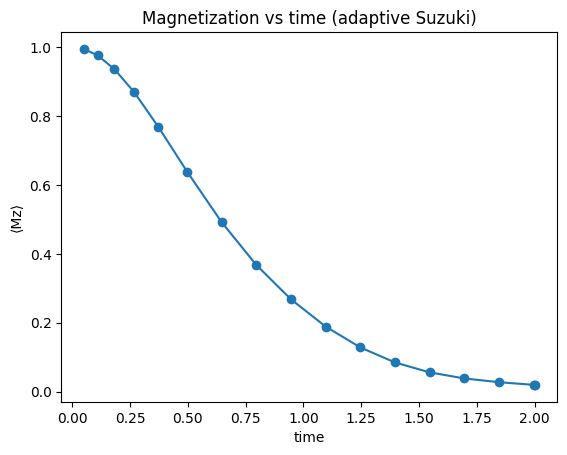

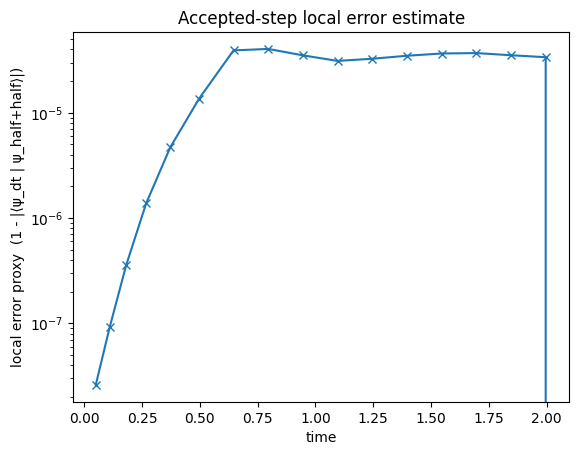

In [4]:
import matplotlib.pyplot as plt

n, J, h, T = 8, 1.0, 1.0, 2.0
schedule, times, errs, mz, qc = adaptive_diagnostics(
    n, J, h, T,
    periodic=False,
    order=2,         # try 4 for stiffer regimes
    tol=2e-3,
    dt_min=5e-4, dt_max=0.15,
    grow=1.2, shrink=0.5
)

print(f"Accepted steps: {len(schedule)}  (first 5: {schedule[:5]})")

# Plot ⟨Mz⟩ vs time
plt.figure()
plt.plot(times, mz, marker='o')
plt.xlabel("time")
plt.ylabel("⟨Mz⟩")
plt.title("Magnetization vs time (adaptive Suzuki)")

# Plot local error proxy per accepted step (use step index or time)
plt.figure()
plt.plot(times, errs, marker='x')
plt.xlabel("time")
plt.ylabel("local error proxy  (1 - |⟨ψ_dt | ψ_half+half⟩|)")
plt.title("Accepted-step local error estimate")
plt.yscale("log")  # often handy since eps is small

plt.show()


# Schwinger Model

Accepted steps: 17  (first 5: [0.05, 0.06, 0.072, 0.08639999999999999, 0.10367999999999998])


/var/folders/n3/vg4hvp1929gff_dhfdv1pw4w0000gq/T/ipykernel_1836/680751928.py:178: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


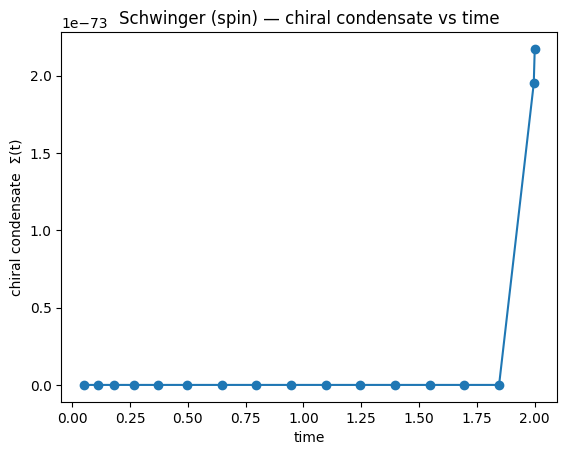

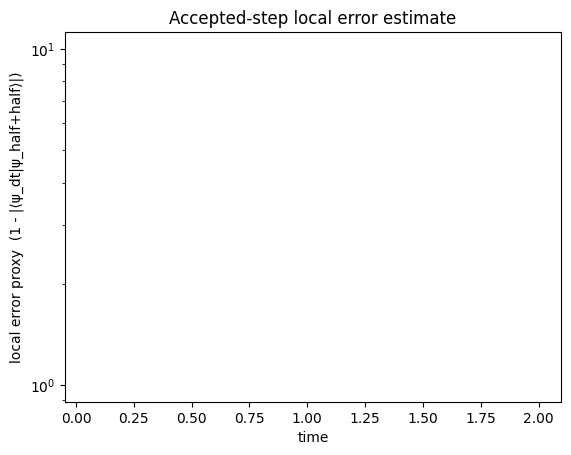

In [9]:
# --- Imports (Qiskit 1.4.x) ---
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis.evolution import SuzukiTrotter
import numpy as np
import matplotlib.pyplot as plt

# ---------- Helpers for Pauli strings with intuitive site indexing ----------
def label_single(n, i, pauli):
    s = ['I'] * n
    s[n-1-i] = pauli  # logical site i -> Qiskit qubit (n-1-i)
    return ''.join(s)

def label_pair(n, i, j, p_i, p_j):
    s = ['I'] * n
    s[n-1-i] = p_i
    s[n-1-j] = p_j
    return ''.join(s)

# ---------- Spin Schwinger Hamiltonian (OBC, Gauss-law eliminated) ----------
def schwinger_spin_hamiltonian(N, x=1.0, m=0.0, g=1.0, ell=0.0, drop_identity=True):
    """
    Build SparsePauliOp for the (1+1)d Schwinger model in spin form (staggered fermions),
    open boundaries. Parameters are dimensionless (a=1 convention):
      - x: hopping strength
      - m: fermion mass
      - g: gauge coupling
      - ell: background field (E_{-1})
    H = H_kin + H_mass + H_E
    """
    terms = {}  # map Pauli string -> coeff (float)

    # --- Kinetic: (x/2) * sum_j (X_j X_{j+1} + Y_j Y_{j+1})
    for j in range(N-1):
        for (p, q) in (('X','X'), ('Y','Y')):
            lab = label_pair(N, j, j+1, p, q)
            terms[lab] = terms.get(lab, 0.0) + (x/2.0)

    # --- Mass: (m/2) * sum_j (-1)^j Z_j
    for j in range(N):
        lab = label_single(N, j, 'Z')
        terms[lab] = terms.get(lab, 0.0) + (m/2.0) * ((-1.0)**j)

    # --- Electric energy after eliminating gauge field:
    # E_n = ell + 1/2 * sum_{j<=n} Z_j + 1/2 * sum_{j<=n} (-1)^j
    # H_E = (g^2/2) * sum_n E_n^2
    alt_prefix = np.cumsum([(-1.0)**j for j in range(N)])  # sum_{j<=n} (-1)^j
    c0 = ell + 0.5 * alt_prefix                       # c0_n for each n

    # Accumulate coefficients for I, Z_j, and ZZ_{j<k}
    coeff_I = 0.0
    coeff_Z = np.zeros(N)
    coeff_ZZ = {}  # (j,k) with j<k -> coeff

    for n in range(N):
        # E_n^2 = c0_n^2 I + c0_n * sum_{j<=n} Z_j + 0.25*(n+1) I + 0.5 * sum_{j<k<=n} Z_j Z_k
        coeff_I += (g**2)/2.0 * (c0[n]**2 + 0.25*(n+1))
        # linear Z_j
        for j in range(n+1):
            coeff_Z[j] += (g**2)/2.0 * c0[n]
        # ZZ_jk
        for j in range(n):
            for k in range(j+1, n+1):
                coeff_ZZ[(j,k)] = coeff_ZZ.get((j,k), 0.0) + (g**2)/4.0

    # Convert linear and quadratic Z contributions into Pauli strings
    for j in range(N):
        if abs(coeff_Z[j]) > 0.0:
            lab = label_single(N, j, 'Z')
            terms[lab] = terms.get(lab, 0.0) + coeff_Z[j]

    for (j,k), c in coeff_ZZ.items():
        if abs(c) > 0.0:
            lab = label_pair(N, j, k, 'Z', 'Z')
            terms[lab] = terms.get(lab, 0.0) + c

    # Optionally drop identity (global phase) since it doesn't affect dynamics/observables
    if not drop_identity and abs(coeff_I) > 0.0:
        terms['I'*N] = terms.get('I'*N, 0.0) + coeff_I

    # Build SparsePauliOp
    paulis = list(terms.keys())
    coeffs = [terms[p] for p in paulis]
    return SparsePauliOp.from_list(list(zip(paulis, coeffs)))

# ---------- Chiral condensate operator Σ = (1/N) Σ (-1)^j Z_j ----------
def chiral_condensate_op(N):
    paulis = []
    coeffs = []
    #for j in range(N):
    #    paulis.append(label_single(N, j, 'Z'))
    #    coeffs.append(((-1.0)**j)/N)
    #return SparsePauliOp.from_list(list(zip(paulis, coeffs)))
    return SparsePauliOp.from_list(
        [(label_single(N, j, 'Z'), -((-1.0)**j)/N) for j in range(N)]
)


# ---------- Evolution gate + local error (embedded pair) ----------
def suzuki_gate(op: SparsePauliOp, dt: float, order=2):
    synth = SuzukiTrotter(order=order, reps=1, insert_barriers=False)
    return PauliEvolutionGate(op, time=dt, synthesis=synth)

def local_error_estimate(op, psi: Statevector, dt: float, order=2):
    n = int(np.log2(psi.data.size))
    qc1 = QuantumCircuit(n); qc1.append(suzuki_gate(op, dt, order), range(n))
    half = dt/2
    qc2 = QuantumCircuit(n); qc2.append(suzuki_gate(op, half, order), range(n)); qc2.append(suzuki_gate(op, half, order), range(n))
    psi1 = psi.evolve(qc1)
    psi2 = psi.evolve(qc2)
    return 1.0 - abs(psi1.data.conj() @ psi2.data)

# ---------- Adaptive controller + diagnostics for Schwinger ----------
def adaptive_schwinger_diagnostics(N, x, m, g, T, ell=0.0, order=2, tol=2e-3,
                                   dt_min=5e-4, dt_max=0.15, grow=1.2, shrink=0.5,
                                   drop_identity=True, psi0=None):
    """
    Returns (schedule, times, errs, condensate, qc, op)
    """
    op = schwinger_spin_hamiltonian(N, x=x, m=m, g=g, ell=ell, drop_identity=drop_identity)
    Sigma = chiral_condensate_op(N)

    psi = psi0 if psi0 is not None else Statevector.from_label('0'*N)
    n = N

    t, dt = 0.0, min(0.05, dt_max)
    schedule, times, errs, cond = [], [], [], []
    qc = QuantumCircuit(n)

    while t < T - 1e-12:
        dt = min(dt, T - t)
        eps = local_error_estimate(op, psi, dt, order=order)
        if eps <= tol or dt <= dt_min + 1e-12:
            # accept
            schedule.append(dt); errs.append(eps)
            gate = suzuki_gate(op, dt, order); qc.append(gate, range(n))
            psi = psi.evolve(gate)
            # chiral condensate after this step
            cond_val = psi.expectation_value(Sigma.to_operator()).real
            cond.append(cond_val)
            t += dt; times.append(t)
            dt = min(dt*grow, dt_max)
        else:
            dt = max(dt*shrink, dt_min)
    return schedule, np.array(times), np.array(errs), np.array(cond), qc, op

# ---------- Example run + plots ----------
if __name__ == "__main__":
    N = 6
    x = 1.0   # hopping
    m = 1.0   # mass
    g = 0.0   # gauge coupling
    ell = 0.0 # background field
    T = 2.0   # total evolution time

    schedule, times, errs, condensate, qc, op = adaptive_schwinger_diagnostics(
        N, x, m, g, T, ell=ell,
        order=2, tol=2e-3,
        dt_min=5e-4, dt_max=0.15, grow=1.2, shrink=0.5,
        drop_identity=True
    )

    print(f"Accepted steps: {len(schedule)}  (first 5: {schedule[:5]})")

    # Plot Σ(t)
    plt.figure()
    plt.plot(times, condensate, marker='o')
    plt.xlabel("time")
    plt.ylabel("chiral condensate  Σ(t)")
    plt.title("Schwinger (spin) — chiral condensate vs time")

    # Plot local error proxy on accepted steps
    plt.figure()
    plt.plot(times, errs, marker='x')
    plt.xlabel("time")
    plt.ylabel("local error proxy  (1 - |⟨ψ_dt|ψ_half+half⟩|)")
    plt.yscale("log")
    plt.title("Accepted-step local error estimate")
    plt.show()


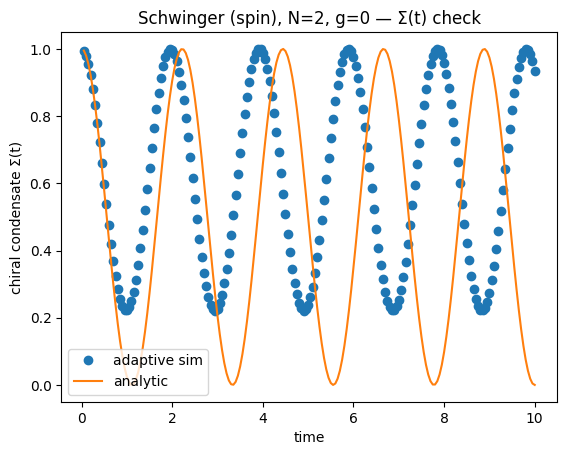

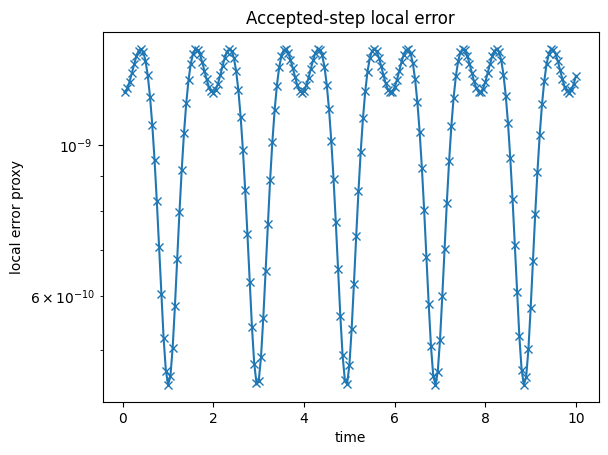

In [12]:
# --- Helper: build a Statevector from site bits (site 0 = leftmost) ---
from qiskit.quantum_info import Statevector

def state_from_sites(site_bits):
    """site_bits: list/tuple of 0/1 of length N (left-to-right sites).
       Returns a Qiskit Statevector in the matching computational basis state."""
    N = len(site_bits)
    # Qiskit's |label> ordering: leftmost char is qubit N-1
    label = ''.join(str(site_bits[N-1-j]) for j in range(N))
    return Statevector.from_label(label)

def neel_bits(N, start_one=True):
    """Return [1,0,1,0,...] if start_one else [0,1,0,1,...]."""
    return [1 if ((j % 2) == 0) == start_one else 0 for j in range(N)]

# --- Two-site analytic sanity check (g=0) ---
import numpy as np
import matplotlib.pyplot as plt

# Use the adaptive Schwinger driver we already wrote, but pass psi0 explicitly
N = 2
x = 1.0
m = 1.0        # try also m=0.4
g = 1.0
T = 10.0       # longer to see several periods

psi0 = state_from_sites([1,0])  # |10> in site order

schedule, times, errs, condensate, qc, op = adaptive_schwinger_diagnostics(
    N, x, m, g, T, ell=0.0,
    order=2, tol=1e-6,            # tight tol so time grid is smooth
    dt_min=1e-4, dt_max=0.05,     # small steps to cleanly track the sine
    grow=1.3, shrink=0.5,
    drop_identity=True,
    psi0=psi0
)

# Analytic curve for N=2
Omega = np.sqrt(m*m + x*x)
sigma_analytic = (m*m + x*x*np.cos(2*Omega*times)) / (Omega*Omega)

# Plot Σ(t) (sim) vs analytic
plt.figure()
plt.plot(times, condensate, marker='o', linestyle='none', label='adaptive sim')
plt.plot(times, sigma_analytic, linewidth=1.5, label='analytic')
plt.xlabel("time")
plt.ylabel("chiral condensate Σ(t)")
plt.title("Schwinger (spin), N=2, g=0 — Σ(t) check")
plt.legend()

# Local error proxy
plt.figure()
plt.plot(times, errs, marker='x')
plt.xlabel("time"); plt.ylabel("local error proxy")
plt.yscale("log"); plt.title("Accepted-step local error")

plt.show()


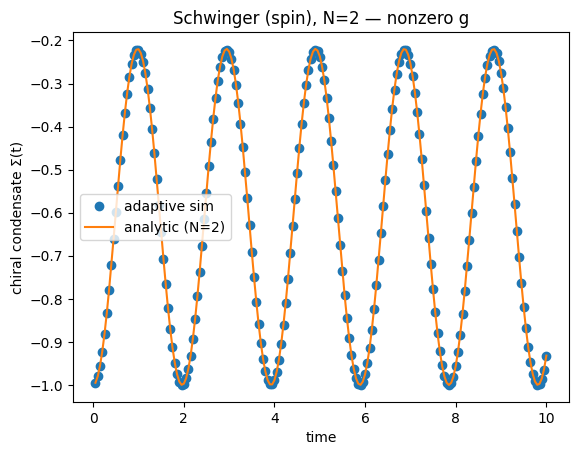

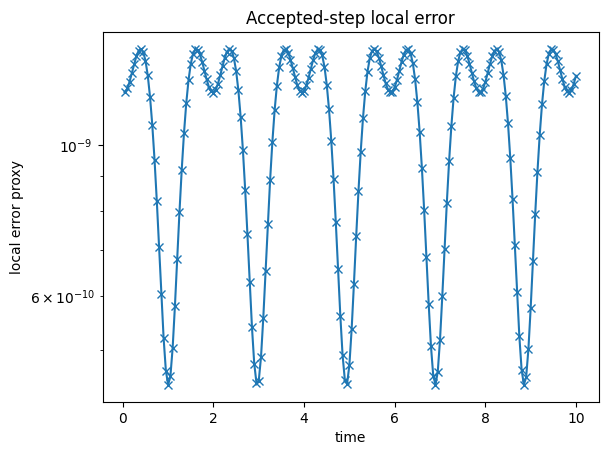

In [14]:
# --- analytic Σ(t) for N=2, any x,m,g,ell; sign_choice = +1 if you want Σ(0)=+1
def sigma_analytic_times(times, x=1.0, m=1.0, g=1.0, ell=0.0, sign_choice=+1):
    b = m + 0.25 * g * g * (2*ell + 1)
    Omega = np.sqrt(x*x + b*b)
    return sign_choice * (b*b + x*x * np.cos(2*Omega*times)) / (Omega*Omega)

# Example: compare to adaptive simulation
N=2; x=m=g=1.0; ell=0.0; T=10.0
psi0 = state_from_sites([0,1])  # choose convention so Σ(0)=+1; or flip sign_choice below

schedule, times, errs, condensate, qc, op = adaptive_schwinger_diagnostics(
    N, x, m, g, T, ell=ell,
    order=2, tol=1e-6, dt_min=1e-4, dt_max=0.05,
    psi0=psi0, drop_identity=True
)

#sigma_th = sigma_analytic_times(times, x=x, m=m, g=g, ell=ell, sign_choice=+1)
sigma_th = -sigma_analytic_times(times, x=x, m=m, g=g, ell=ell, sign_choice=+1)


plt.figure()
plt.plot(times, condensate, marker='o', linestyle='none', label='adaptive sim')
plt.plot(times, sigma_th, label='analytic (N=2)')
plt.xlabel("time"); plt.ylabel("chiral condensate Σ(t)")
plt.title("Schwinger (spin), N=2 — nonzero g")
plt.legend()

plt.figure()
plt.plot(times, errs, marker='x')
plt.yscale("log"); plt.xlabel("time"); plt.ylabel("local error proxy")
plt.title("Accepted-step local error")
plt.show()


In [15]:
import numpy as np

def sigma_exact_vs_time(op, Sigma, psi0, times):
    """Exact Σ(t) using spectral decomposition of H defined by `op`."""
    H = op.to_operator().data          # dense Hermitian 2^N x 2^N
    E, V = np.linalg.eigh(H)           # H = V diag(E) V†
    alpha = V.conj().T @ psi0.data     # |ψ0> in eigenbasis
    S = Sigma.to_operator().data
    S_tilde = V.conj().T @ S @ V       # Σ in eigenbasis

    sig = []
    for t in times:
        phase = np.exp(-1j * E * t)         # exp(-i E t)
        psi_t = phase * alpha               # coefficients of |ψ(t)>
        val = np.vdot(psi_t, S_tilde @ psi_t)
        sig.append(val.real)
    return np.array(sig)


/var/folders/n3/vg4hvp1929gff_dhfdv1pw4w0000gq/T/ipykernel_1836/1468758185.py:7: RuntimeWarning: divide by zero encountered in matmul
  alpha = V.conj().T @ psi0.data     # |ψ0> in eigenbasis
/var/folders/n3/vg4hvp1929gff_dhfdv1pw4w0000gq/T/ipykernel_1836/1468758185.py:7: RuntimeWarning: overflow encountered in matmul
  alpha = V.conj().T @ psi0.data     # |ψ0> in eigenbasis
/var/folders/n3/vg4hvp1929gff_dhfdv1pw4w0000gq/T/ipykernel_1836/1468758185.py:7: RuntimeWarning: invalid value encountered in matmul
  alpha = V.conj().T @ psi0.data     # |ψ0> in eigenbasis
/var/folders/n3/vg4hvp1929gff_dhfdv1pw4w0000gq/T/ipykernel_1836/1468758185.py:9: RuntimeWarning: divide by zero encountered in matmul
  S_tilde = V.conj().T @ S @ V       # Σ in eigenbasis
/var/folders/n3/vg4hvp1929gff_dhfdv1pw4w0000gq/T/ipykernel_1836/1468758185.py:9: RuntimeWarning: overflow encountered in matmul
  S_tilde = V.conj().T @ S @ V       # Σ in eigenbasis
/var/folders/n3/vg4hvp1929gff_dhfdv1pw4w0000gq/T/ipykernel_

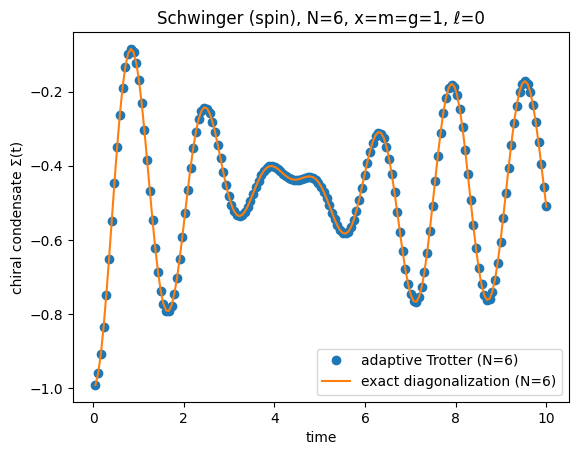

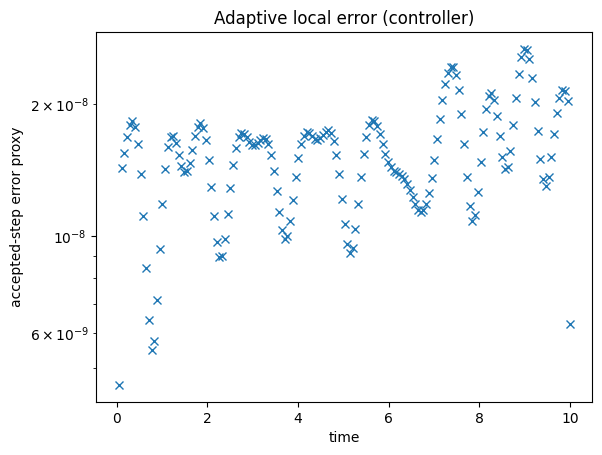

max |ΔΣ| = 0.005254058197984579


In [16]:
# Choose an initial state with Σ(0)=+1 (nice for plotting): |010101>
N = 6
x = m = g = 1.0
ell = 0.0
T = 10.0

psi0 = state_from_sites([0,1,0,1,0,1])   # Néel, Σ(0)=+1
Sigma = chiral_condensate_op(N)

# Adaptive Trotter (same driver as before)
schedule, times, errs, condensate, qc, op = adaptive_schwinger_diagnostics(
    N, x, m, g, T, ell=ell,
    order=2, tol=2e-4, dt_min=2e-4, dt_max=0.06, grow=1.25, shrink=0.5,
    drop_identity=True, psi0=psi0
)

# Exact curve at the *same* time stamps
sigma_ed = sigma_exact_vs_time(op, Sigma, psi0, times)

# Plot
import matplotlib.pyplot as plt
plt.figure()
plt.plot(times, condensate, 'o', label='adaptive Trotter (N=6)')
plt.plot(times, sigma_ed, '-',  label='exact diagonalization (N=6)')
plt.xlabel("time"); plt.ylabel("chiral condensate Σ(t)")
plt.title("Schwinger (spin), N=6, x=m=g=1, ℓ=0")
plt.legend()

plt.figure()
plt.plot(times, errs, 'x')
plt.yscale("log")
plt.xlabel("time"); plt.ylabel("accepted-step error proxy")
plt.title("Adaptive local error (controller)")
plt.show()

print("max |ΔΣ| =", np.max(np.abs(condensate - sigma_ed)))


In [17]:
def prefix_circuits_from_schedule(N, op, schedule, order=2):
    circs = []
    acc = QuantumCircuit(N)
    for dt in schedule:
        acc.append(suzuki_gate(op, dt, order), range(N))
        circs.append(acc.copy())
    return circs

# Example:
prefix_circs = prefix_circuits_from_schedule(N, op, schedule, order=2)
# Send [(circ, [Sigma])] batched through EstimatorV2 to get Σ(t_k)


## Hardware

In [ ]:
# ==== Imports ====
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis.evolution import SuzukiTrotter
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2
import numpy as np
import matplotlib.pyplot as plt

# ===== Utilities: Pauli labels with intuitive site indexing =====
def label_single(n, i, pauli):
    s = ['I'] * n
    s[n-1-i] = pauli  # site i -> qubit n-1-i
    return ''.join(s)

def label_pair(n, i, j, p_i, p_j):
    s = ['I'] * n
    s[n-1-i] = p_i
    s[n-1-j] = p_j
    return ''.join(s)

def state_from_sites(site_bits):
    N = len(site_bits)
    label = ''.join(str(site_bits[N-1-j]) for j in range(N))
    return Statevector.from_label(label)

# ===== Schwinger (spin) Hamiltonian, OBC, Gauss-law eliminated =====
def schwinger_spin_hamiltonian(N, x=1.0, m=1.0, g=1.0, ell=0.0, drop_identity=True):
    terms = {}

    # Kinetic: (x/2) Σ (X_i X_{i+1} + Y_i Y_{i+1})
    for j in range(N-1):
        for (p, q) in (('X','X'), ('Y','Y')):
            lab = label_pair(N, j, j+1, p, q)
            terms[lab] = terms.get(lab, 0.0) + (x/2.0)

    # Mass: (m/2) Σ (-1)^j Z_j
    for j in range(N):
        lab = label_single(N, j, 'Z')
        terms[lab] = terms.get(lab, 0.0) + (m/2.0) * ((-1.0)**j)

    # Electric energy: H_E = (g^2/2) Σ_n E_n^2,  E_n = ell + 1/2 Σ_{j<=n} Z_j + 1/2 Σ_{j<=n} (-1)^j
    alt_prefix = np.cumsum([(-1.0)**j for j in range(N)])  # Σ_{j<=n} (-1)^j
    c0 = ell + 0.5 * alt_prefix

    coeff_I = 0.0
    coeff_Z = np.zeros(N)
    coeff_ZZ = {}  # (j,k) j<k

    for n in range(N):
        coeff_I += (g**2)/2.0 * (c0[n]**2 + 0.25*(n+1))
        for j in range(n+1):
            coeff_Z[j] += (g**2)/2.0 * c0[n]
        for j in range(n):
            for k in range(j+1, n+1):
                coeff_ZZ[(j,k)] = coeff_ZZ.get((j,k), 0.0) + (g**2)/4.0

    for j in range(N):
        if abs(coeff_Z[j]) > 0.0:
            lab = label_single(N, j, 'Z')
            terms[lab] = terms.get(lab, 0.0) + coeff_Z[j]

    for (j,k), c in coeff_ZZ.items():
        if abs(c) > 0.0:
            lab = label_pair(N, j, k, 'Z', 'Z')
            terms[lab] = terms.get(lab, 0.0) + c

    if not drop_identity and abs(coeff_I) > 0.0:
        terms['I'*N] = terms.get('I'*N, 0.0) + coeff_I

    paulis = list(terms.keys())
    coeffs = [terms[p] for p in paulis]
    return SparsePauliOp.from_list(list(zip(paulis, coeffs)))

# ===== Chiral condensate Σ = (1/N) Σ (-1)^j Z_j (choose sign so Σ(|0101..>)=+1) =====
def chiral_condensate_op(N, sign_flip=False):
    paulis, coeffs = [], []
    sgn = -1.0 if sign_flip else +1.0
    for j in range(N):
        paulis.append(label_single(N, j, 'Z'))
        coeffs.append(sgn * ((-1.0)**j)/N)
    return SparsePauliOp.from_list(list(zip(paulis, coeffs)))

# ===== Evolution + local error (embedded pair) =====
def suzuki_gate(op: SparsePauliOp, dt: float, order=2):
    return PauliEvolutionGate(op, time=dt, synthesis=SuzukiTrotter(order=order, reps=1, insert_barriers=False))

def local_error_estimate(op, psi: Statevector, dt: float, order=2):
    n = int(np.log2(psi.data.size))
    q1 = QuantumCircuit(n); q1.append(suzuki_gate(op, dt, order), range(n))
    half = dt/2
    q2 = QuantumCircuit(n); q2.append(suzuki_gate(op, half, order), range(n)); q2.append(suzuki_gate(op, half, order), range(n))
    p1 = psi.evolve(q1)
    p2 = psi.evolve(q2)
    return 1.0 - abs(p1.data.conj() @ p2.data)

# ===== Adaptive controller (records times, error, Σ) =====
def adaptive_schwinger_diagnostics(N, x, m, g, T, ell=0.0, order=2, tol=2e-3,
                                   dt_min=5e-4, dt_max=0.15, grow=1.2, shrink=0.5,
                                   drop_identity=True, psi0=None, sign_flip=False):
    op = schwinger_spin_hamiltonian(N, x=x, m=m, g=g, ell=ell, drop_identity=drop_identity)
    Sigma = chiral_condensate_op(N, sign_flip=sign_flip)
    psi = psi0 if psi0 is not None else Statevector.from_label('0'*N)

    t, dt = 0.0, min(0.05, dt_max)
    schedule, times, errs, cond = [], [], [], []
    qc = QuantumCircuit(N)

    while t < T - 1e-12:
        dt = min(dt, T - t)
        eps = local_error_estimate(op, psi, dt, order=order)
        if eps <= tol or dt <= dt_min + 1e-12:
            schedule.append(dt); errs.append(eps)
            gate = suzuki_gate(op, dt, order); qc.append(gate, range(N))
            psi = psi.evolve(gate)
            cond_val = psi.expectation_value(Sigma.to_operator()).real
            cond.append(cond_val)
            t += dt; times.append(t)
            dt = min(dt*grow, dt_max)
        else:
            dt = max(dt*shrink, dt_min)
    return schedule, np.array(times), np.array(errs), np.array(cond), qc, op, Sigma

# ===== Build prefix circuits (one circuit per accepted time) =====
def prefix_circuits_from_schedule(N, op, schedule, order=2):
    circs = []
    acc = QuantumCircuit(N)
    for dt in schedule:
        acc.append(suzuki_gate(op, dt, order), range(N))
        circs.append(acc.copy())
    return circs

# ===== Chunk helper for long schedules =====
def chunked(seq, n):
    for i in range(0, len(seq), n):
        yield seq[i:i+n]

# ======== USER CONFIG =========
N = 6
x = m = g = 1.0
ell = 0.0
T = 10.0
ORDER = 2               # 2 or 4
TOL = 2e-4              # tighten for higher fidelity (more steps)
DT_MIN, DT_MAX = 2e-4, 0.06
# Choose initial state with Σ(0)=+1 for nice phase (Néel |0101...>)
psi0 = state_from_sites([0,1,0,1,0,1])
SIGN_FLIP = False       # keep Σ definition consistent with Σ(0)=+1 above

# Preferred backend + layout (trim to N)
BACKEND_NAME = "ibm_rensselaer"
PREFERRED_LAYOUT_13 = [37, 52, 56, 57, 58, 59, 60, 61, 62, 72, 81, 80, 79]  # your noted layout
INITIAL_LAYOUT = PREFERRED_LAYOUT_13[:N]   # use first N physical qubits

SHOTS = 20000
MAX_CIRCS_PER_JOB = 100   # safety; backends often allow many more

# ======== 1) Build adaptive schedule offline (statevector) ========
schedule, times, errs, condensate_sim, qc_full, op, Sigma = adaptive_schwinger_diagnostics(
    N, x, m, g, T, ell=ell,
    order=ORDER, tol=TOL, dt_min=DT_MIN, dt_max=DT_MAX,
    drop_identity=True, psi0=psi0, sign_flip=SIGN_FLIP
)

print(f"Accepted steps: {len(schedule)}")
prefix_circs = prefix_circuits_from_schedule(N, op, schedule, order=ORDER)

# ======== 2) Connect to IBM and transpile ========
#service = QiskitRuntimeService(channel="ibm_quantum")  # or "ibm_cloud"
service = QiskitRuntimeService()
backend = service.backend("ibm_rensselaer")
#backend = service.backend(BACKEND_NAME)

tprefix = transpile(
    prefix_circs,
    backend=backend,
    initial_layout=INITIAL_LAYOUT,
    optimization_level=2,          # safe default; try 3 if mapping is stable
)

# ======== 3) EstimatorV2 run on hardware ========
est = EstimatorV2(backend=backend)

# Optional runtime settings (guarded for version differences)
opt = getattr(est, "options", None)
if opt is not None:
    # DD
    if getattr(opt, "dynamical_decoupling", None) is not None:
        opt.dynamical_decoupling.enable = True
    # Twirling
    if getattr(opt, "twirling", None) is not None:
        opt.twirling.enable = True
        if getattr(opt.twirling, "standard_gates", None) is not None:
            opt.twirling.standard_gates = ["cx", "rz", "sx"]
    # Transpilation hints (some versions expose this)
    if getattr(opt, "transpilation", None) is not None:
        opt.transpilation.optimization_level = 2
    # Measurement error mitigation (if present in your stack)
    if getattr(opt, "resilience", None) is not None and getattr(opt.resilience, "measurement_error_mitigation", None) is not None:
        opt.resilience.measurement_error_mitigation = True

# Build inputs: one pair per prefix circuit; pass [Sigma] so evs is a vector
inputs = [(c, [Sigma]) for c in tprefix]

# Some backends prefer chunking very long batches
sigma_hw = []
for batch in chunked(inputs, MAX_CIRCS_PER_JOB):
    job = est.run(batch, shots=SHOTS)
    res = job.result()
    # res is an iterable of results; each .data.evs is scalar or length-1
    sigma_hw.extend([float(np.atleast_1d(r.data.evs)[0]) for r in res])

sigma_hw = np.array(sigma_hw)

# ======== 4) Plot hardware vs. statevector baseline & error proxy ========
plt.figure()
plt.plot(times, condensate_sim, "o", label="adaptive (statevector)")
plt.plot(times, sigma_hw, "-", label=f"hardware {BACKEND_NAME}")
plt.xlabel("time"); plt.ylabel("chiral condensate Σ(t)")
plt.title(f"Schwinger (spin), N={N} — hardware vs simulation")
plt.legend()

plt.figure()
plt.plot(times, errs, "x")
plt.yscale("log")
plt.xlabel("time"); plt.ylabel("accepted-step local error proxy")
plt.title("Adaptive controller diagnostics")
plt.show()


Accepted steps: 167
